# Breast Cancer Prediction using Machine Learning

In [ ]:
# Problem Statement

* Breast cancer is one of the most common cancers among women worldwide.
* Early diagnosis improves treatment outcomes. 
* This project aims to predict whether a breast tumor is Benign or Malignant using machine learning algorithms.

In [ ]:
# Business Objective

* Develop a classification model that helps identify malignant tumors accurately to assist healthcare professionals in early diagnosis.

In [4]:
# Importing All Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score )

In [5]:
# Load_CSV_File
breast_cancer_df =pd.read_csv(r'C:\Users\Admin\Downloads\BreastCancer.csv')

In [ ]:
# Data_Understanding

In [6]:
breast_cancer_df.head()

,Unnamed: 0,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1,1000025,5,1,1,1,2,1.0,3,1,1,benign
1,2,1002945,5,4,4,5,7,10.0,3,2,1,benign
2,3,1015425,3,1,1,1,2,2.0,3,1,1,benign
3,4,1016277,6,8,8,1,3,4.0,3,7,1,benign
4,5,1017023,4,1,1,3,2,1.0,3,1,1,benign


In [7]:
breast_cancer_df.tail()

,Unnamed: 0,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
694,695,776715,3,1,1,1,3,2.0,1,1,1,benign
695,696,841769,2,1,1,1,2,1.0,1,1,1,benign
696,697,888820,5,10,10,3,7,3.0,8,10,2,malignant
697,698,897471,4,8,6,4,3,4.0,10,6,1,malignant
698,699,897471,4,8,8,5,4,5.0,10,4,1,malignant


In [8]:
breast_cancer_df.sample(5)

,Unnamed: 0,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
506,507,1286943,8,10,10,10,7,5.0,4,8,7,malignant
684,685,466906,1,1,1,1,2,1.0,1,1,1,benign
319,320,721482,4,4,4,4,6,5.0,7,3,1,benign
365,366,897172,2,1,1,1,2,1.0,2,1,1,benign
76,77,1132347,1,1,4,1,2,1.0,2,1,1,benign


In [9]:
# Check_shape
breast_cancer_df.shape

(699, 12)

In [10]:
# Check_Columns
breast_cancer_df.columns

Index(['Unnamed: 0', 'Id', 'Cl.thickness', 'Cell.size', 'Cell.shape',
       'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin',
       'Normal.nucleoli', 'Mitoses', 'Class'],
      dtype='object')

In [11]:
# Check_Dataset_Information
breast_cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       699 non-null    int64  
 1   Id               699 non-null    int64  
 2   Cl.thickness     699 non-null    int64  
 3   Cell.size        699 non-null    int64  
 4   Cell.shape       699 non-null    int64  
 5   Marg.adhesion    699 non-null    int64  
 6   Epith.c.size     699 non-null    int64  
 7   Bare.nuclei      683 non-null    float64
 8   Bl.cromatin      699 non-null    int64  
 9   Normal.nucleoli  699 non-null    int64  
 10  Mitoses          699 non-null    int64  
 11  Class            699 non-null    object 
dtypes: float64(1), int64(10), object(1)
memory usage: 65.7+ KB


In [12]:
# Statistical_Summary
breast_cancer_df.describe()

,Unnamed: 0,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
count,699.000000,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,350.000000,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,201.928205,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,175.500000,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,350.000000,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,524.500000,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,699.000000,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [13]:
# Check_Missing_Value
breast_cancer_df.isnull().sum()

Unnamed: 0          0
Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64

In [14]:
breast_cancer_df.isnull().sum()[breast_cancer_df.isnull().sum()>1]

Bare.nuclei    16
dtype: int64

In [15]:
# Fill_Null
breast_cancer_df['Bare.nuclei']=breast_cancer_df['Bare.nuclei'].fillna(breast_cancer_df['Bare.nuclei'].mean())

In [16]:
breast_cancer_df.isnull().sum()[breast_cancer_df.isnull().sum()>1]

Series([], dtype: int64)

In [17]:
# Drop_Columns
breast_cancer_df = breast_cancer_df.drop(['Unnamed: 0'] , axis = 1)
breast_cancer_df = breast_cancer_df.drop(['Id'] , axis = 1)

In [18]:
breast_cancer_df.head(1)

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,benign


In [ ]:
# convert class into o 0 and 1
breast_cancer_df['Class'] = breast_cancer_df['Class'].map({
    'benign': 0,
    'malignant': 1})

In [34]:
breast_cancer_df.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
# EDA

In [20]:
breast_cancer_df.columns

Index(['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion',
       'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli',
       'Mitoses', 'Class'],
      dtype='object')

In [21]:
breast_cancer_df['Class'].value_counts()

Class
benign       458
malignant    241
Name: count, dtype: int64

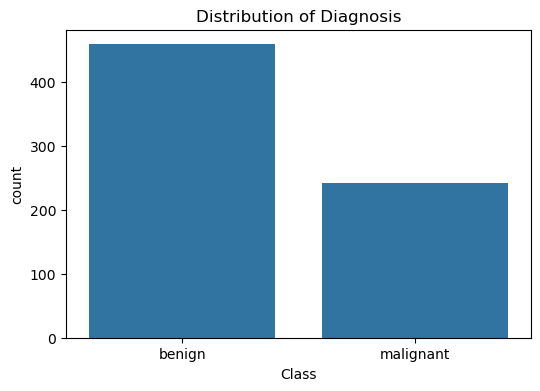

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=breast_cancer_df)
plt.title("Distribution of Diagnosis")
plt.show()

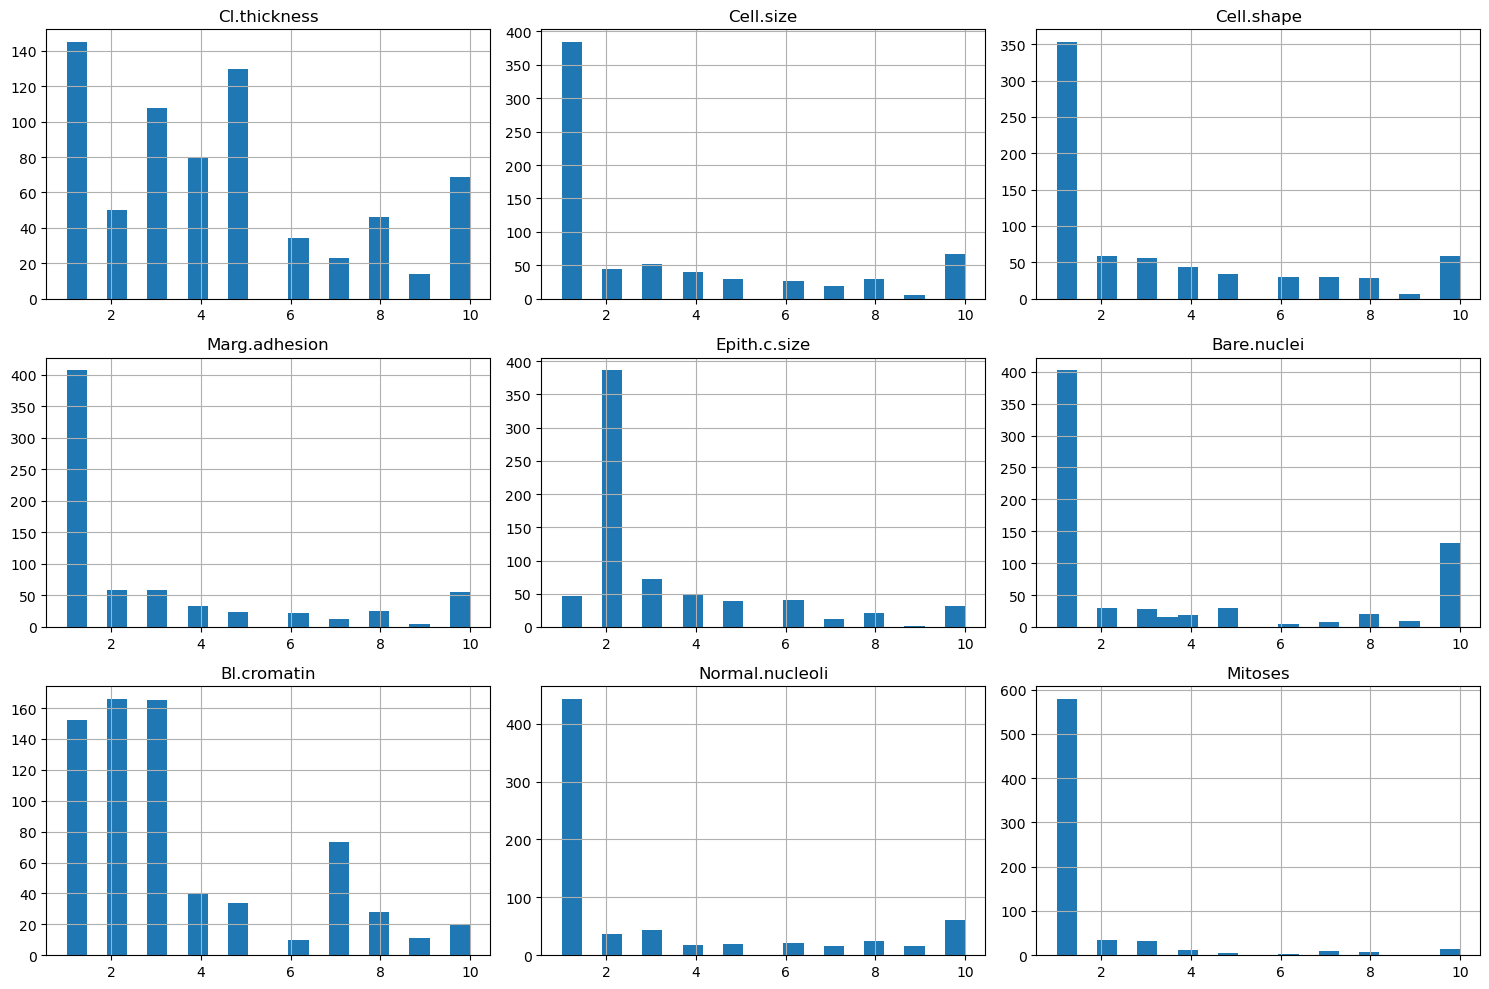

In [23]:
breast_cancer_df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

* Some features are right-skewed.
* Some features are evenly distributed.
* Most values lie between specific ranges.

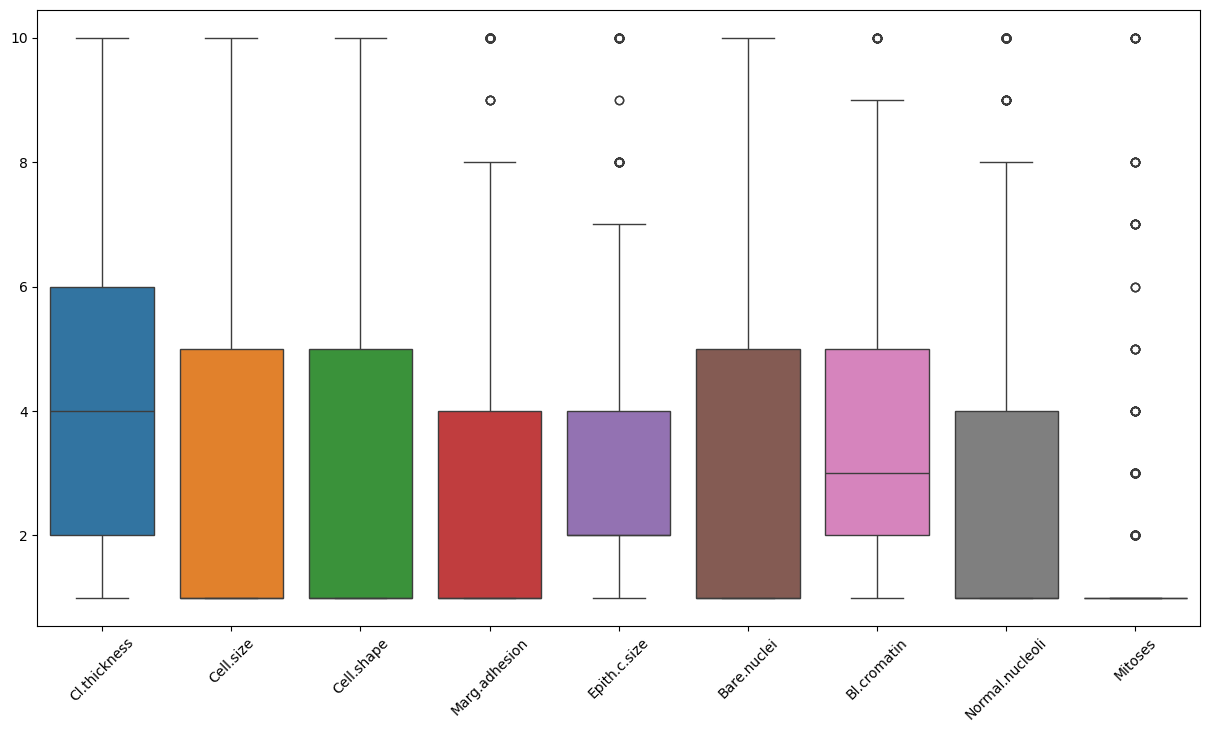

In [24]:
# Outlier Detection
plt.figure(figsize=(15,8))
sns.boxplot(data=breast_cancer_df)
plt.xticks(rotation=45)
plt.show()

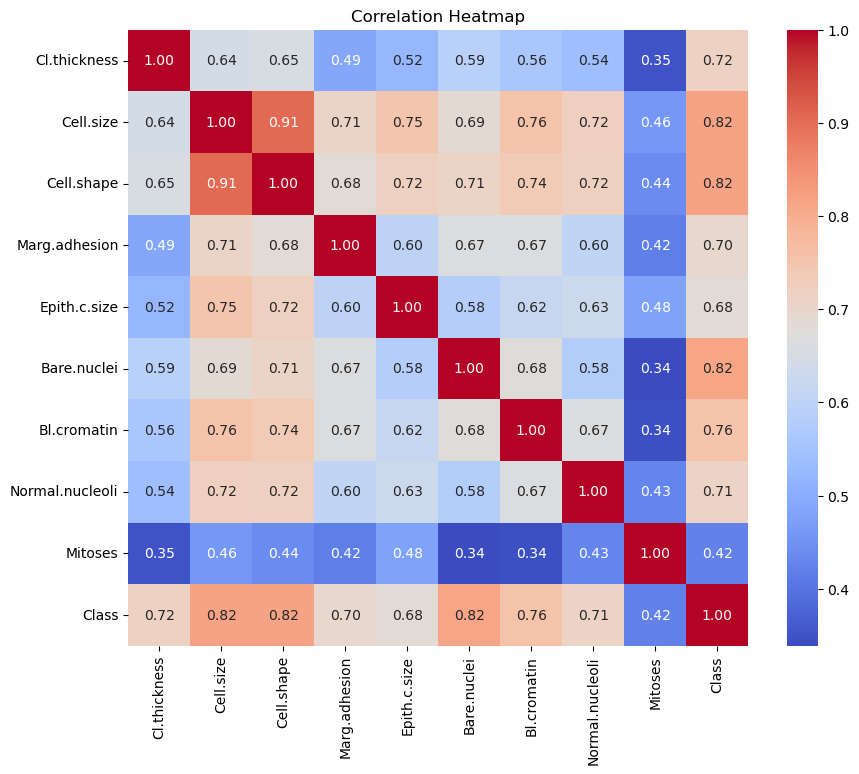

In [32]:
# Corelation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    breast_cancer_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

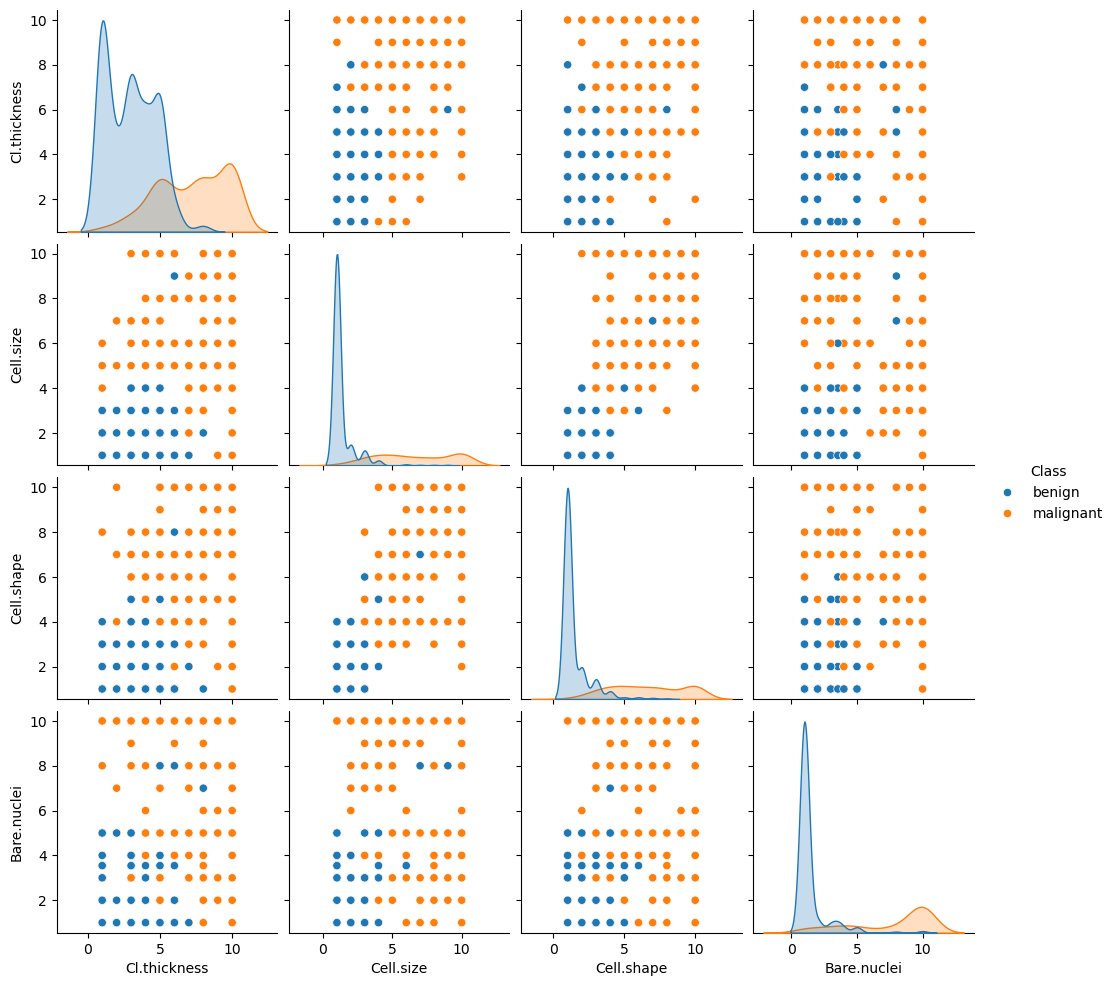

In [26]:
selected = [
    'Cl.thickness',
    'Cell.size',
    'Cell.shape',
    'Bare.nuclei',
    'Class']

sns.pairplot(
    breast_cancer_df[selected],
    hue='Class')

In [33]:
corr = breast_cancer_df.corr()['Class'].sort_values(ascending=False)

print(corr)

Class              1.000000
Cell.shape         0.818934
Cell.size          0.817904
Bare.nuclei        0.816050
Bl.cromatin        0.756616
Cl.thickness       0.716001
Normal.nucleoli    0.712244
Marg.adhesion      0.696800
Epith.c.size       0.682785
Mitoses            0.423170
Name: Class, dtype: float64


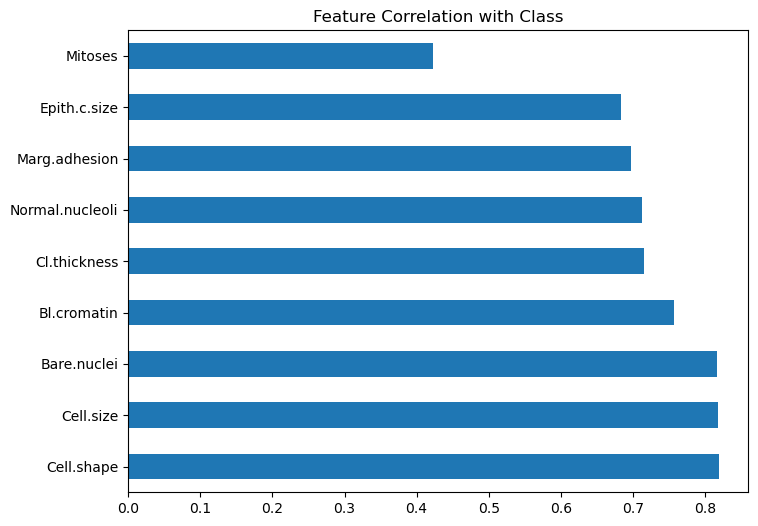

In [35]:
corr.drop('Class').plot(kind='barh', figsize=(8,6))
plt.title("Feature Correlation with Class")
plt.show()

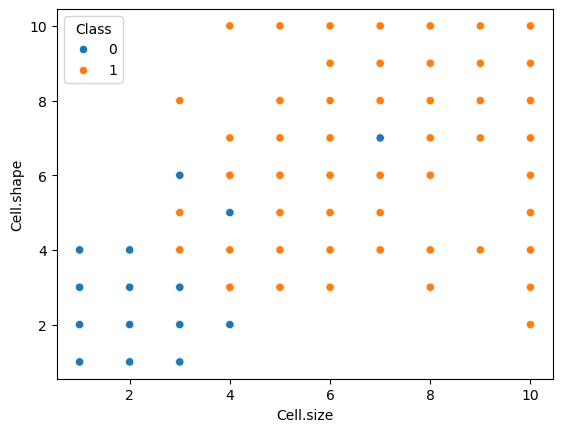

In [36]:
# check feature relationship

sns.scatterplot(
    x='Cell.size',
    y='Cell.shape',
    hue='Class',
    data=breast_cancer_df)

plt.show()

In [37]:
# Data Preprocessing
breast_cancer_df.isnull().sum()

Cl.thickness       0
Cell.size          0
Cell.shape         0
Marg.adhesion      0
Epith.c.size       0
Bare.nuclei        0
Bl.cromatin        0
Normal.nucleoli    0
Mitoses            0
Class              0
dtype: int64

In [38]:
breast_cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Cl.thickness     699 non-null    int64  
 1   Cell.size        699 non-null    int64  
 2   Cell.shape       699 non-null    int64  
 3   Marg.adhesion    699 non-null    int64  
 4   Epith.c.size     699 non-null    int64  
 5   Bare.nuclei      699 non-null    float64
 6   Bl.cromatin      699 non-null    int64  
 7   Normal.nucleoli  699 non-null    int64  
 8   Mitoses          699 non-null    int64  
 9   Class            699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [39]:
# feature sepration
X = breast_cancer_df.drop('Class', axis=1)

y = breast_cancer_df['Class']

In [40]:
print(X.shape)
print(y.shape)

(699, 9)
(699,)


In [42]:
from sklearn.model_selection import train_test_split
breast_cancer_train , breast_cancer_test  = train_test_split(breast_cancer_df, test_size=.2 , random_state=111)

brec_train_x=breast_cancer_train.iloc[ : , 0:-1 ]
brec_train_y=breast_cancer_train.iloc[ :  , -1  ]

brec_test_x=breast_cancer_test.iloc[ : , 0:-1 ]
brec_test_y=breast_cancer_test.iloc[ : ,  -1  ]

In [44]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(brec_train_x, brec_train_y)
pred_dt = model_dt.predict(brec_test_x)

In [46]:
# Model Evaluation

print("Confusion Matrix")
print(confusion_matrix(brec_test_y, pred_dt))
print("\nClassification Report")
print(classification_report(brec_test_y, pred_dt))
print("------------------------")
print("Accuracy :", accuracy_score(brec_test_y, pred_dt))
print("Precision:", precision_score(brec_test_y, pred_dt))
print("Recall   :", recall_score(brec_test_y, pred_dt))
print("F1 Score :", f1_score(brec_test_y, pred_dt))

Confusion Matrix
[[91  3]
 [ 4 42]]

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        94
           1       0.93      0.91      0.92        46

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140

------------------------
Accuracy : 0.95
Precision: 0.9333333333333333
Recall   : 0.9130434782608695
F1 Score : 0.9230769230769231


In [47]:
# Logistic Model
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(brec_train_x, brec_train_y)
pred_lr = model_lr.predict(brec_test_x)

In [49]:
# Model Evaluation

print("Confusion Matrix")
print(confusion_matrix(brec_test_y, pred_lr))
print("\nClassification Report")
print(classification_report(brec_test_y, pred_lr))
print("------------------------")
print("Accuracy :", accuracy_score(brec_test_y, pred_lr))
print("Precision:", precision_score(brec_test_y, pred_lr))
print("Recall   :", recall_score(brec_test_y, pred_lr))
print("F1 Score :", f1_score(brec_test_y, pred_lr))

Confusion Matrix
[[91  3]
 [ 1 45]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        94
           1       0.94      0.98      0.96        46

    accuracy                           0.97       140
   macro avg       0.96      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

------------------------
Accuracy : 0.9714285714285714
Precision: 0.9375
Recall   : 0.9782608695652174
F1 Score : 0.9574468085106383


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(brec_train_x, brec_train_y)

pred_rf = model_rf.predict(brec_test_x)

In [50]:
# RandomForest Model

from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(brec_train_x, brec_train_y)
pred_rf = model_rf.predict(brec_test_x)

In [51]:
# Model Evaluation
print("Random Forest")
print(confusion_matrix(brec_test_y, pred_rf))
print("--------------------------------")
print("Accuracy :", accuracy_score(brec_test_y, pred_rf))
print("Precision:", precision_score(brec_test_y, pred_rf))
print("Recall   :", recall_score(brec_test_y, pred_rf))
print("F1 Score :", f1_score(brec_test_y, pred_rf))
print(classification_report(brec_test_y, pred_rf))

Random Forest
[[92  2]
 [ 1 45]]
--------------------------------
Accuracy : 0.9785714285714285
Precision: 0.9574468085106383
Recall   : 0.9782608695652174
F1 Score : 0.967741935483871
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        94
           1       0.96      0.98      0.97        46

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



In [52]:
# SVM Model

from sklearn.svm import SVC
model_svm = SVC(random_state=42)
model_svm.fit(brec_train_x, brec_train_y)
pred_svm = model_svm.predict(brec_test_x)

In [53]:
# Model Evaluation

print("Support Vector Machine")
print(confusion_matrix(brec_test_y, pred_svm))
print("--------------------------------")
print("Accuracy :", accuracy_score(brec_test_y, pred_svm))
print("Precision:", precision_score(brec_test_y, pred_svm))
print("Recall   :", recall_score(brec_test_y, pred_svm))
print("F1 Score :", f1_score(brec_test_y, pred_svm))
print(classification_report(brec_test_y, pred_svm))

Support Vector Machine
[[90  4]
 [ 1 45]]
--------------------------------
Accuracy : 0.9642857142857143
Precision: 0.9183673469387755
Recall   : 0.9782608695652174
F1 Score : 0.9473684210526315
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        94
           1       0.92      0.98      0.95        46

    accuracy                           0.96       140
   macro avg       0.95      0.97      0.96       140
weighted avg       0.97      0.96      0.96       140



In [54]:
# Comparision Table
compare_result = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','SVM'],
    
    'Accuracy': [accuracy_score(brec_test_y, pred_lr),accuracy_score(brec_test_y, pred_dt),accuracy_score(brec_test_y, pred_rf),
                 accuracy_score(brec_test_y, pred_svm)],
    'Precision': [ precision_score(brec_test_y, pred_lr),precision_score(brec_test_y, pred_dt), precision_score(brec_test_y, pred_rf),
                precision_score(brec_test_y, pred_svm)],
    'Recall': [recall_score(brec_test_y, pred_lr),recall_score(brec_test_y, pred_dt),recall_score(brec_test_y, pred_rf),
                recall_score(brec_test_y, pred_svm)],
    'F1 Score': [ f1_score(brec_test_y, pred_lr), f1_score(brec_test_y, pred_dt), f1_score(brec_test_y, pred_rf),
                  f1_score(brec_test_y, pred_svm)]})

In [55]:
compare_result

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.971429,0.937500,0.978261,0.957447
1,Decision Tree,0.950000,0.933333,0.913043,0.923077
2,Random Forest,0.978571,0.957447,0.978261,0.967742
3,SVM,0.964286,0.918367,0.978261,0.947368


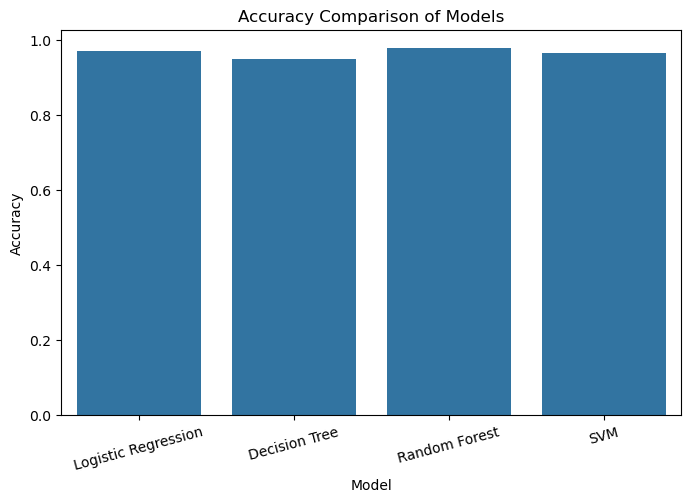

In [57]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=compare_result)

plt.xticks(rotation=15)
plt.title("Accuracy Comparison of Models")
plt.show()

In [58]:
# Hyperparametr tunning for dt
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy')

grid.fit(brec_train_x,brec_train_y)

print(grid.best_params_)
print(grid.best_score_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.9481177606177607


In [60]:
# Cross Validation

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_rf,X,y,cv=5)
print(scores)
print(scores.mean())

[0.92857143 0.94285714 0.97142857 0.98571429 0.99280576]
0.9642754367934223


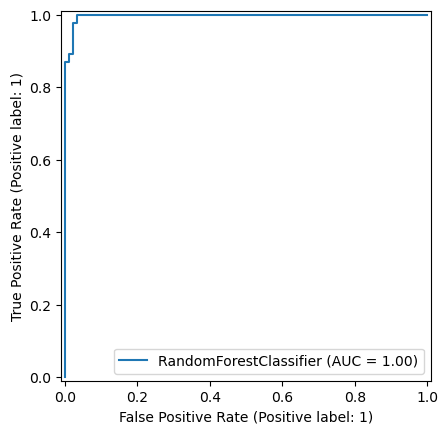

In [61]:
# ROC Curve

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model_rf,brec_test_x,brec_test_y)
plt.show()

In [71]:
# Feature Importance

feat_imp  = pd.DataFrame()
feat_imp['Features']= brec_train_x.columns
feat_imp['Importance']= model_rf.feature_importances_
feat_imp

,Features,Importance
0,Cl.thickness,0.047644
1,Cell.size,0.327827
2,Cell.shape,0.237107
3,Marg.adhesion,0.019778
4,Epith.c.size,0.059943
5,Bare.nuclei,0.142117
6,Bl.cromatin,0.075661
7,Normal.nucleoli,0.082748
8,Mitoses,0.007173


In [73]:
feat_imp = feat_imp.sort_values(by='Importance',ascending=False)
feat_imp

,Features,Importance
1,Cell.size,0.327827
2,Cell.shape,0.237107
5,Bare.nuclei,0.142117
7,Normal.nucleoli,0.082748
6,Bl.cromatin,0.075661
4,Epith.c.size,0.059943
0,Cl.thickness,0.047644
3,Marg.adhesion,0.019778
8,Mitoses,0.007173


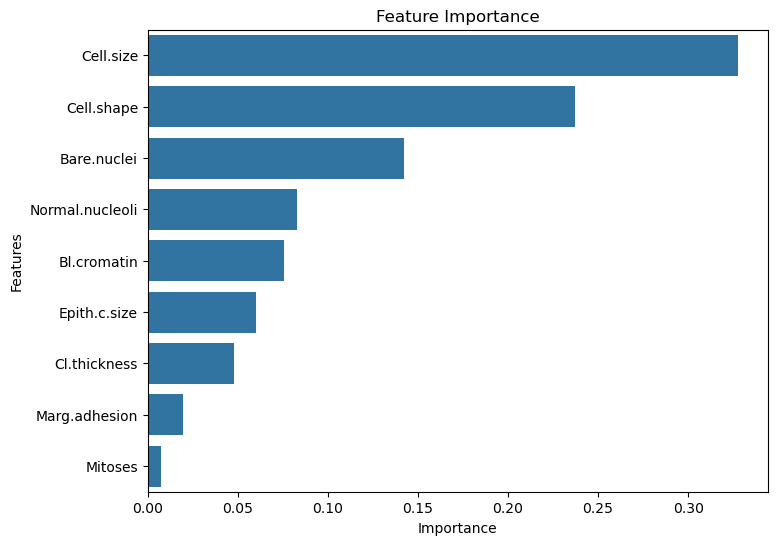

In [74]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance',y='Features', data=feat_imp)

plt.title("Feature Importance")
plt.show()

In [75]:
import joblib

joblib.dump(
    model_rf,
    'breast_cancer_model.pkl')

['breast_cancer_model.pkl']

* Conclusion
  
This project developed a machine learning model to classify breast tumors as Benign or Malignant using the Wisconsin Breast Cancer dataset. The project followed a complete machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model building, evaluation, hyperparameter tuning, and model interpretation.

Four classification algorithms—Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM)—were trained and evaluated using metrics such as Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. The models were compared to identify the most effective approach for breast cancer classification. Hyperparameter tuning further improved the performance of the Decision Tree model, and feature importance analysis highlighted the most influential predictors in the dataset.

The results demonstrate that machine learning can accurately classify breast cancer cases and has the potential to support healthcare professionals in early diagnosis and decision-making. However, this model should be considered a decision-support tool and not a replacement for clinical expertise.

* Key Takeaways
* Successfully completed an end-to-end machine learning pipeline.
* Performed comprehensive EDA to understand feature relationships and data quality.
* Built and compared four classification models.
* Improved model performance using hyperparameter tuning.
* Evaluated models using multiple performance metrics.
* Identified the most influential features through feature importance analysis.
* Saved the best-performing model for future predictions.